# Actividad. Payoff Diagrams con datos reales

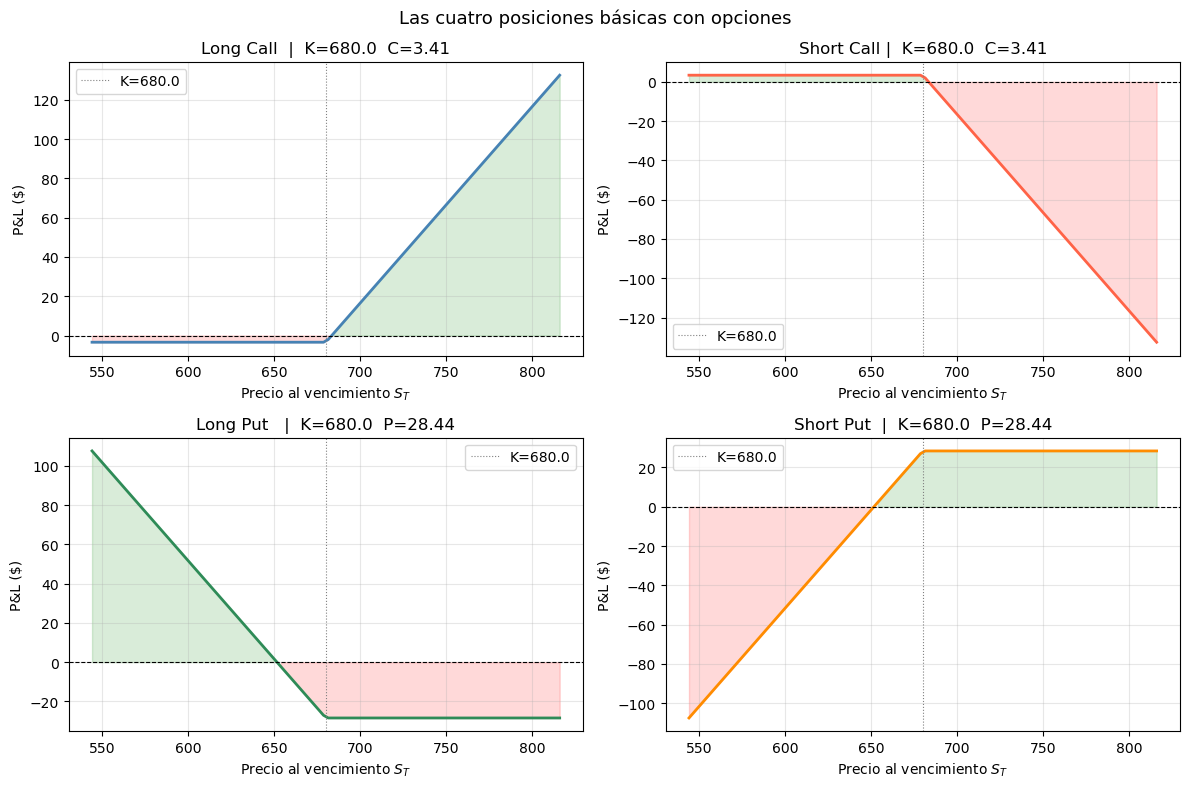

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

# --- 1. Configuración inicial ---
tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'
K   = 680

calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

# --- 2. Encontrar el strike real más cercano ---
K_exact = calls.iloc[(calls['strike'] - K).abs().argsort()[:1]]['strike'].values[0]

row_call = calls[calls['strike'] == K_exact].iloc[0]
row_put  = puts[puts['strike'] == K_exact].iloc[0]

C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid']  + row_put['ask'])  / 2

# --- 3. Vector de precios del subyacente al vencimiento (ST) ---
ST = np.linspace(K_exact * 0.8, K_exact * 1.2, 100)

# --- Payoffs brutos (usando ST en lugar de la columna de strikes) ---
call_long_bruto  =  np.maximum(ST - K_exact, 0)
call_short_bruto = -np.maximum(ST - K_exact, 0)
put_long_bruto   =  np.maximum(K_exact - ST, 0)
put_short_bruto  = -np.maximum(K_exact - ST, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

# --- 4. Gráficos ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K_exact}  C={C:.2f}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call |  K={K_exact}  C={C:.2f}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K_exact}  P={P:.2f}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K_exact}  P={P:.2f}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(ST, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K_exact, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_exact}')
    
    # Se actualizan los fill_between para usar ST
    ax.fill_between(ST, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(ST, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones', fontsize=13)
plt.tight_layout()
plt.show()

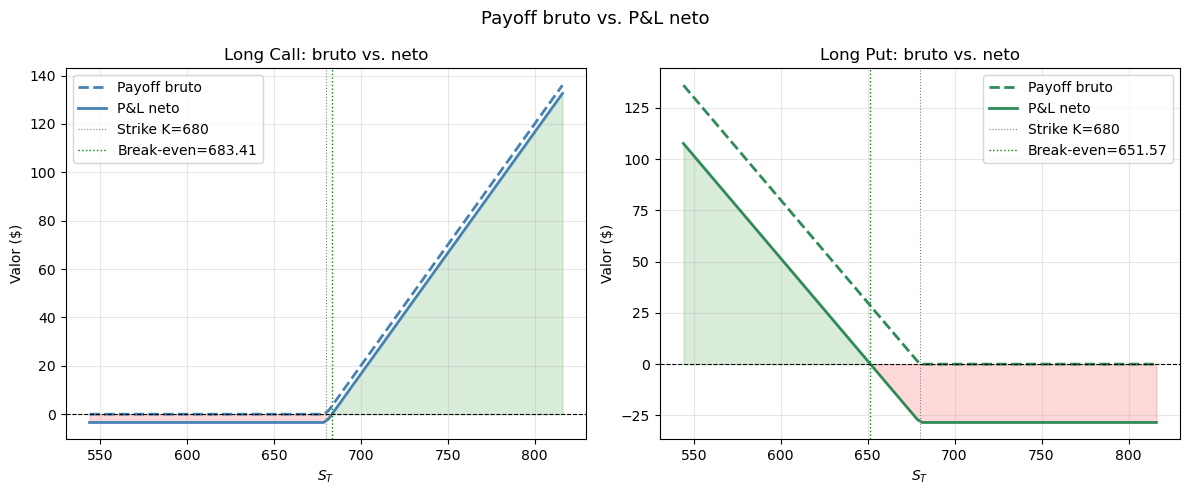

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Long call: comparación bruto vs neto
axes[0].plot(ST, call_long_bruto, color='steelblue',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[0].plot(ST, pnl_call_long,   color='steelblue',
             linewidth=2, label='P&L neto')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(K,     color='gray', linewidth=0.8,
                linestyle=':', label=f'Strike K={K}')
axes[0].axvline(K + C, color='green', linewidth=1.0,
                linestyle=':', label=f'Break-even={K+C:.2f}')
axes[0].fill_between(ST, pnl_call_long, 0,
                     where=(pnl_call_long > 0), alpha=0.15, color='green')
axes[0].fill_between(ST, pnl_call_long, 0,
                     where=(pnl_call_long < 0), alpha=0.15, color='red')
axes[0].set_title('Long Call: bruto vs. neto')
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Valor ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Long put: comparación bruto vs neto
axes[1].plot(ST, put_long_bruto, color='seagreen',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[1].plot(ST, pnl_put_long,   color='seagreen',
             linewidth=2, label='P&L neto')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(K,     color='gray',  linewidth=0.8,
                linestyle=':', label=f'Strike K={K}')
axes[1].axvline(K - P, color='green', linewidth=1.0,
                linestyle=':', label=f'Break-even={K-P:.2f}')
axes[1].fill_between(ST, pnl_put_long, 0,
                     where=(pnl_put_long > 0), alpha=0.15, color='green')
axes[1].fill_between(ST, pnl_put_long, 0,
                     where=(pnl_put_long < 0), alpha=0.15, color='red')
axes[1].set_title('Long Put: bruto vs. neto')
axes[1].set_xlabel('$S_T$')
axes[1].set_ylabel('Valor ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Payoff bruto vs. P&L neto', fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
data = {
    "Posición": ["Long Call", "Short Call", "Long Put", "Short Put"],
    "Fórmula": ["K + C", "K + C", "K - P", "K - P"],
    "Valor Break-even": [K + C, K + C, K - P, K - P]
}

df_be = pd.DataFrame(data)
print(df_be)
print("Precio de hoy: $", S0)

     Posición Fórmula  Valor Break-even
0   Long Call   K + C           683.410
1  Short Call   K + C           683.410
2    Long Put   K - P           651.565
3   Short Put   K - P           651.565
Precio de hoy: $ 653.1799926757812


### Respuestas a las Preguntas:

- Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?

Las posiciones put tienen un break-even más cercano al precio. Eso significa que el precio tiene que moverse poquito para poder empezar a ganar dinero en las posiciones long, o perder dinero en las posiciones short.

- Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?

Si termina en K, Las posiciones long pierden el precio de la prima, mientras las short ganan el precio de la prima.

- Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?

La short put tiene mucho más riesgo ya que puede perder el todo lo que costó la acción, mientras el long call tiene topada la pérdida al precio de la prima.

- ¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?

Long put, ya que no me gusta la idea de perder infinita cantidad de dinero. 